## Homework B01: Weekend Submission of BMJ Journal
Prabhakar Srivastava

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import jax.numpy as jnp
from jax import vmap
from jax.random import PRNGKey, split
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import arviz as az
from jax.scipy.special import expit

Random Seed and Plotting Style

In [2]:
random_seed = sum(map(ord, "Homework B01: Statistical Rethinking Numpyro"))

az.style.use("arviz-doc")

numpyro.set_host_device_count(4)

Read in the Data

In [3]:
file_path_str:str = "https://raw.githubusercontent.com/rmcelreath/stat_rethinking_2026/main/homework/BMJSubmissions.csv"

df = pd.read_csv(file_path_str, sep=",")
df.head()

,T,Y,country_name,L,W,H
0,11.766667,2012,Canada,7,0,0
1,10.516667,2012,Italy,18,0,0
2,13.516667,2012,Netherlands,21,0,0
3,19.483333,2012,United Kingdom,37,0,0
4,14.400000,2012,United Kingdom,37,0,0


Plot weekend acceptance rate by country

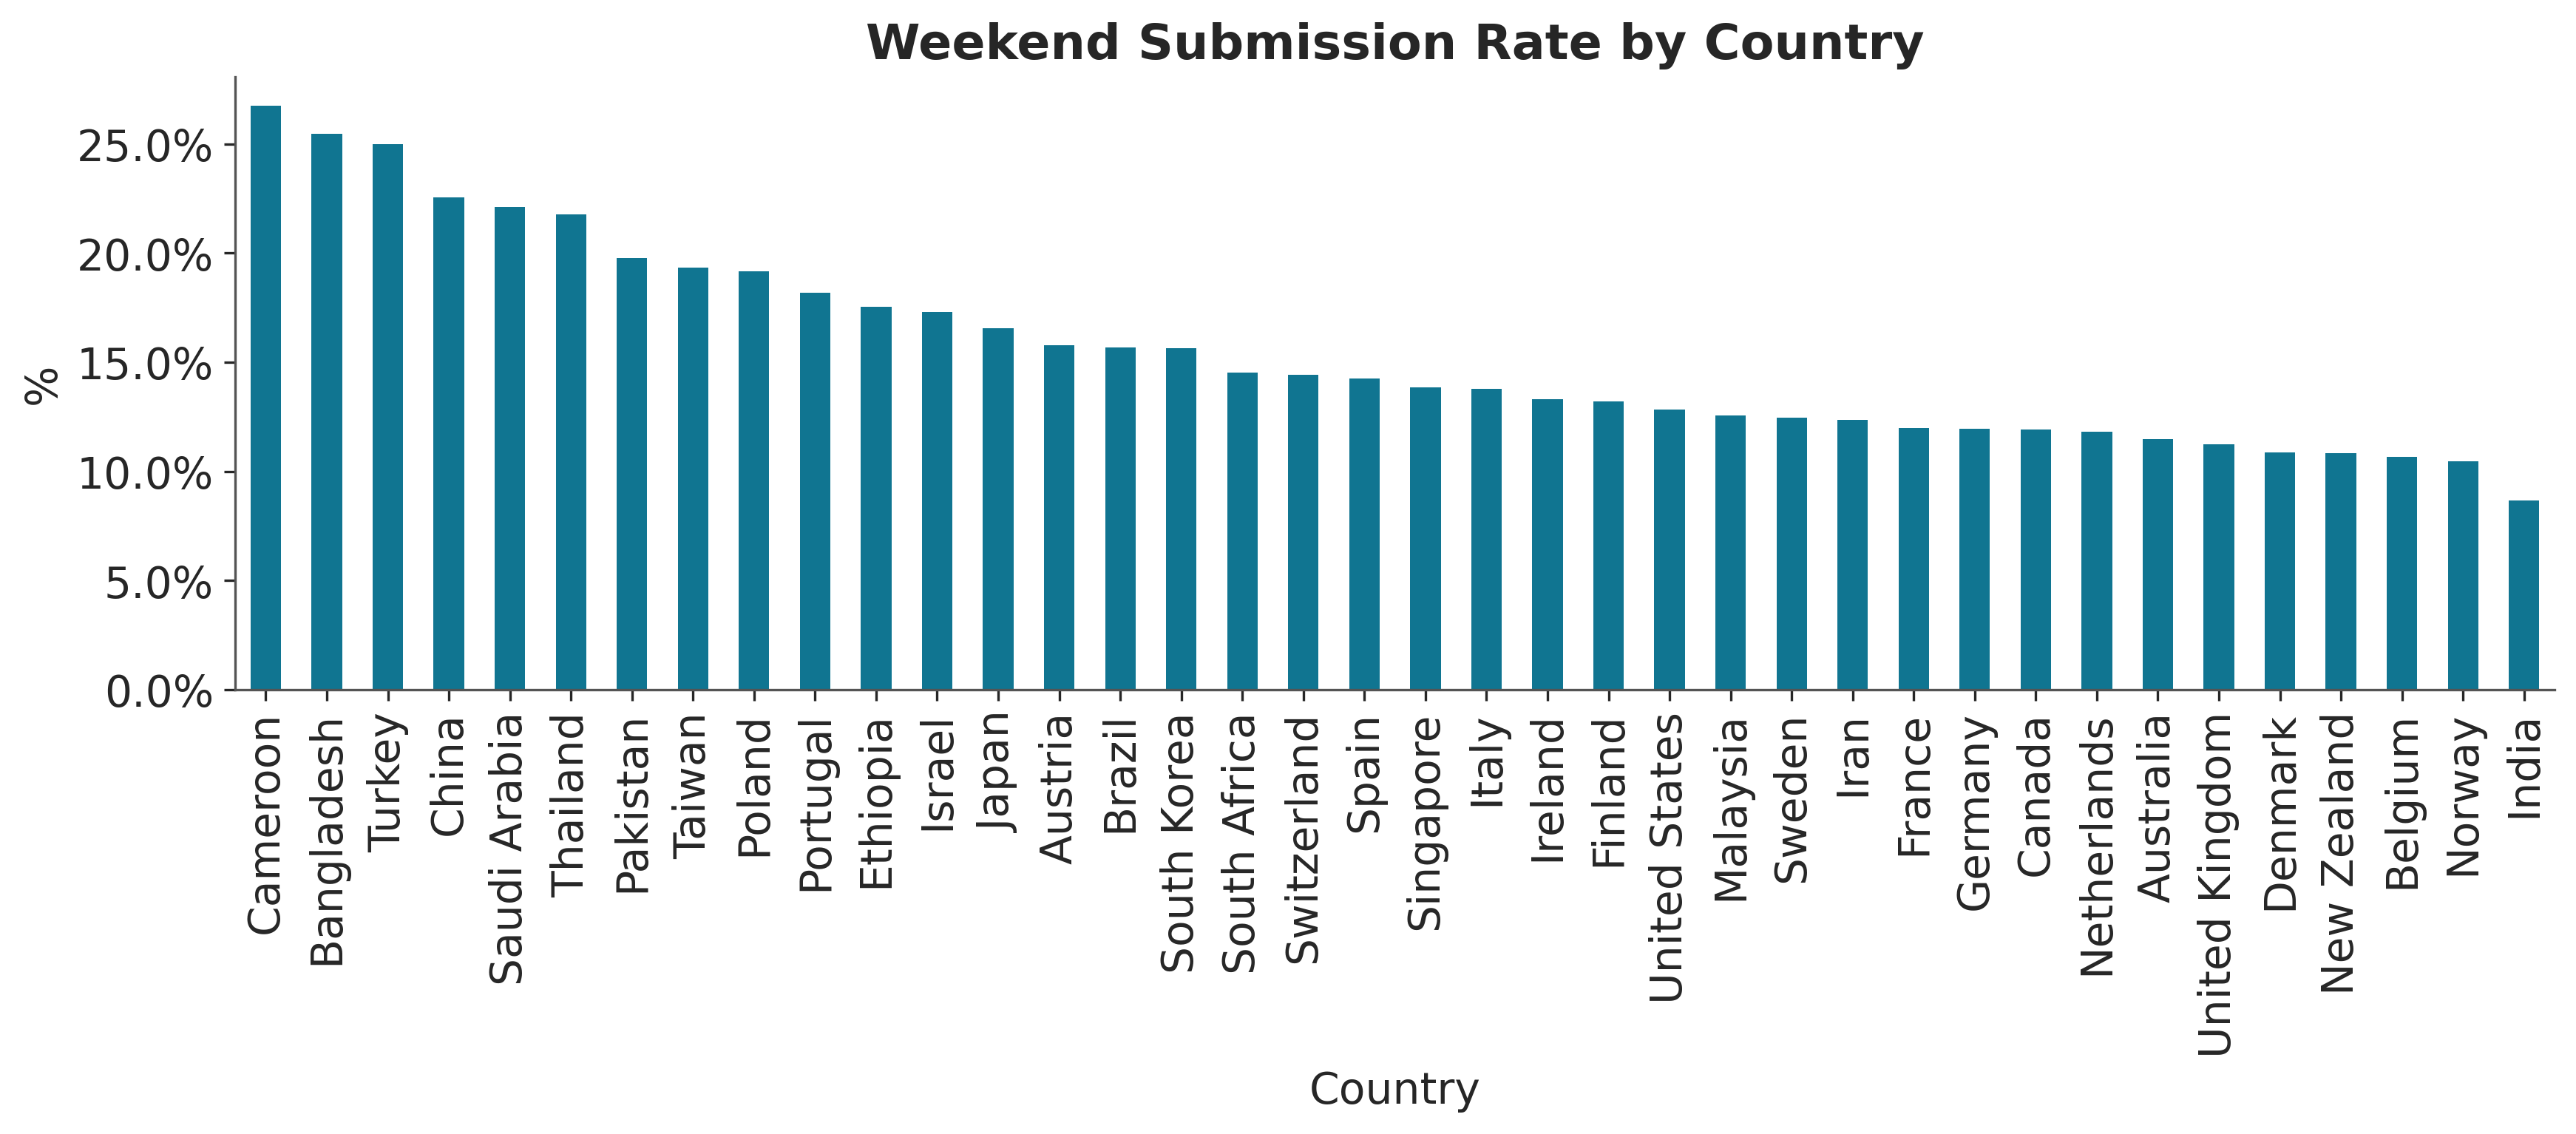

In [4]:
summary_df = (
    df
    .groupby("country_name")
    ["W"]
    .mean()
    .reset_index()
    .sort_values(by="W", ascending=False)
)

fig, ax = plt.subplots()
summary_df.plot(x="country_name", y="W", ax=ax, kind="bar")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.get_legend().remove()
ax.set_ylabel("%")
ax.set_xlabel("Country")
ax.set_title("Weekend Submission Rate by Country")
plt.show()

No Pooling model <br>
<center> $W \sim Bernoulli(p)$</center>
<center> $p = invlogit(a + b[\text{country\_id}])$</center>
<center> $a \sim Normal(-2, 1)$</center>
<center> $b[\text{country\_id}] \sim Normal(0, 0.5)$</center>

In [5]:
country_idx, countries = pd.factorize(df["country_name"], sort=True)
country_dict = {c:i for i, c in enumerate(countries)}
country_dict_sorted = {c:country_dict[c] for c in summary_df["country_name"].values}

In [6]:
def no_pooled_model(country_id:jnp.array=jnp.array(country_idx), W:jnp.array=jnp.array(df["W"].values)) -> None:
    '''
    No pooled model for weekend submission
    '''

    # Priors
    a = numpyro.sample("a", dist.Normal(loc=-2., scale=1.))
    
    # No pooled priors for countries
    n_countries = len(np.unique(country_id))

    with numpyro.plate("n_country", n_countries):
        b = numpyro.sample("b", dist.Normal(loc=0., scale=0.5))

    # Probability
    μ = a + b[country_id]

    # Likelihood
    likelihood = numpyro.sample("likelihood", dist.Bernoulli(expit(μ)), obs=W)
    

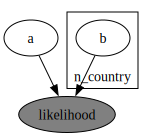

In [7]:
numpyro.render_model(no_pooled_model)

In [8]:
rng_key = PRNGKey(random_seed)
rng_key, rng_subkey = split(rng_key)

no_pooled_mcmc = MCMC(NUTS(no_pooled_model), num_warmup=1_000, num_samples=2_000, num_chains=4)
no_pooled_mcmc.run(rng_subkey)
no_pooled_mcmc.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -1.75      0.08     -1.75     -1.89     -1.61    759.77      1.00
      b[0]     -0.29      0.10     -0.29     -0.45     -0.13    992.73      1.00
      b[1]      0.06      0.21      0.06     -0.29      0.39   4156.48      1.00
      b[2]      0.56      0.22      0.56      0.19      0.91   4513.27      1.00
      b[3]     -0.34      0.18     -0.34     -0.63     -0.03   3449.02      1.00
      b[4]      0.06      0.14      0.07     -0.16      0.29   1922.23      1.00
      b[5]      0.61      0.22      0.61      0.24      0.97   4352.33      1.00
      b[6]     -0.25      0.10     -0.24     -0.41     -0.08   1049.24      1.00
      b[7]      0.52      0.09      0.52      0.38      0.67    829.55      1.00
      b[8]     -0.35      0.12     -0.34     -0.53     -0.15   1425.21      1.00
      b[9]      0.17      0.18      0.18     -0.14      0.46   3046.63      1.00
     b[10]     -0.13      0

In [9]:
no_pooled_samples = no_pooled_mcmc.get_samples()
prob_weekend_no_pooled_ = vmap(lambda a, b: expit(a + b), in_axes=(0, 0))(no_pooled_samples["a"], no_pooled_samples["b"]) 

In [10]:
# Look at trace plot
idata_no_pooled = az.from_numpyro(
    no_pooled_mcmc,
    coords={"country": countries},
    dims={"b":["country"]}
    
)

In [11]:
az.summary(idata_no_pooled, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.75,0.08,-1.91,-1.60,0.0,0.0,763.86,1176.49,1.00
b[Australia],-0.29,0.10,-0.47,-0.10,0.0,0.0,993.01,1604.13,1.00
b[Austria],0.06,0.21,-0.33,0.45,0.0,0.0,4162.31,5253.37,1.00
b[Bangladesh],0.56,0.22,0.15,0.96,0.0,0.0,4526.73,6164.00,1.00
b[Belgium],-0.34,0.18,-0.68,0.01,0.0,0.0,3457.04,4854.37,1.00
b[Brazil],0.06,0.14,-0.19,0.32,0.0,0.0,1932.87,3103.95,1.00
b[Cameroon],0.61,0.22,0.20,1.02,0.0,0.0,4403.55,4770.28,1.00
b[Canada],-0.25,0.10,-0.43,-0.05,0.0,0.0,1054.08,2047.17,1.00
b[China],0.52,0.09,0.35,0.69,0.0,0.0,831.99,1415.41,1.00
b[Denmark],-0.35,0.12,-0.56,-0.12,0.0,0.0,1434.77,2696.01,1.00


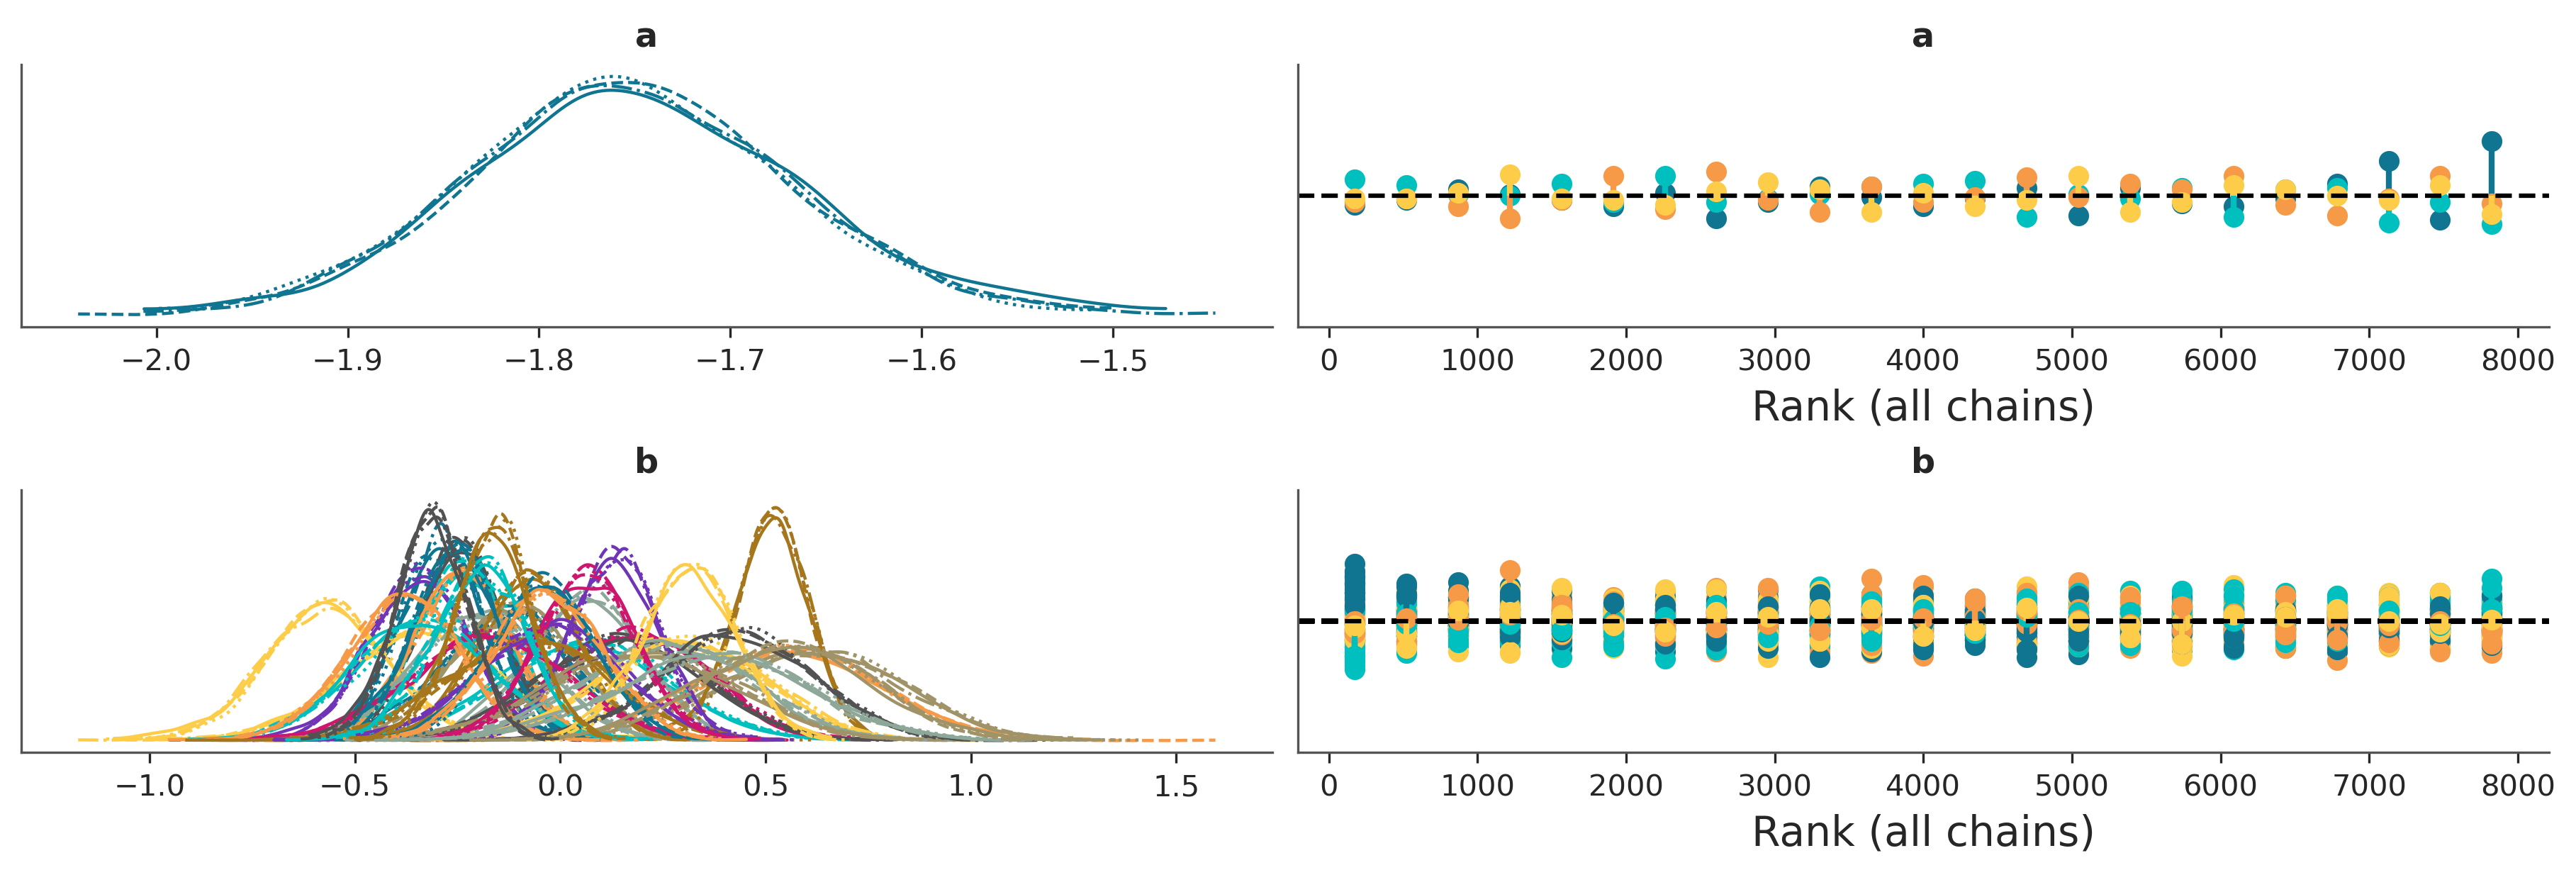

In [12]:
az.plot_trace(idata_no_pooled, kind="rank_vlines")
plt.show()

In [13]:
prob_weekend_no_pool = az.from_dict(
    posterior={"prob_weekend": 
               prob_weekend_no_pooled_.reshape(4, 2_000, -1)},
    coords={"country": countries},
    dims={"prob_weekend": ["country"]}
)

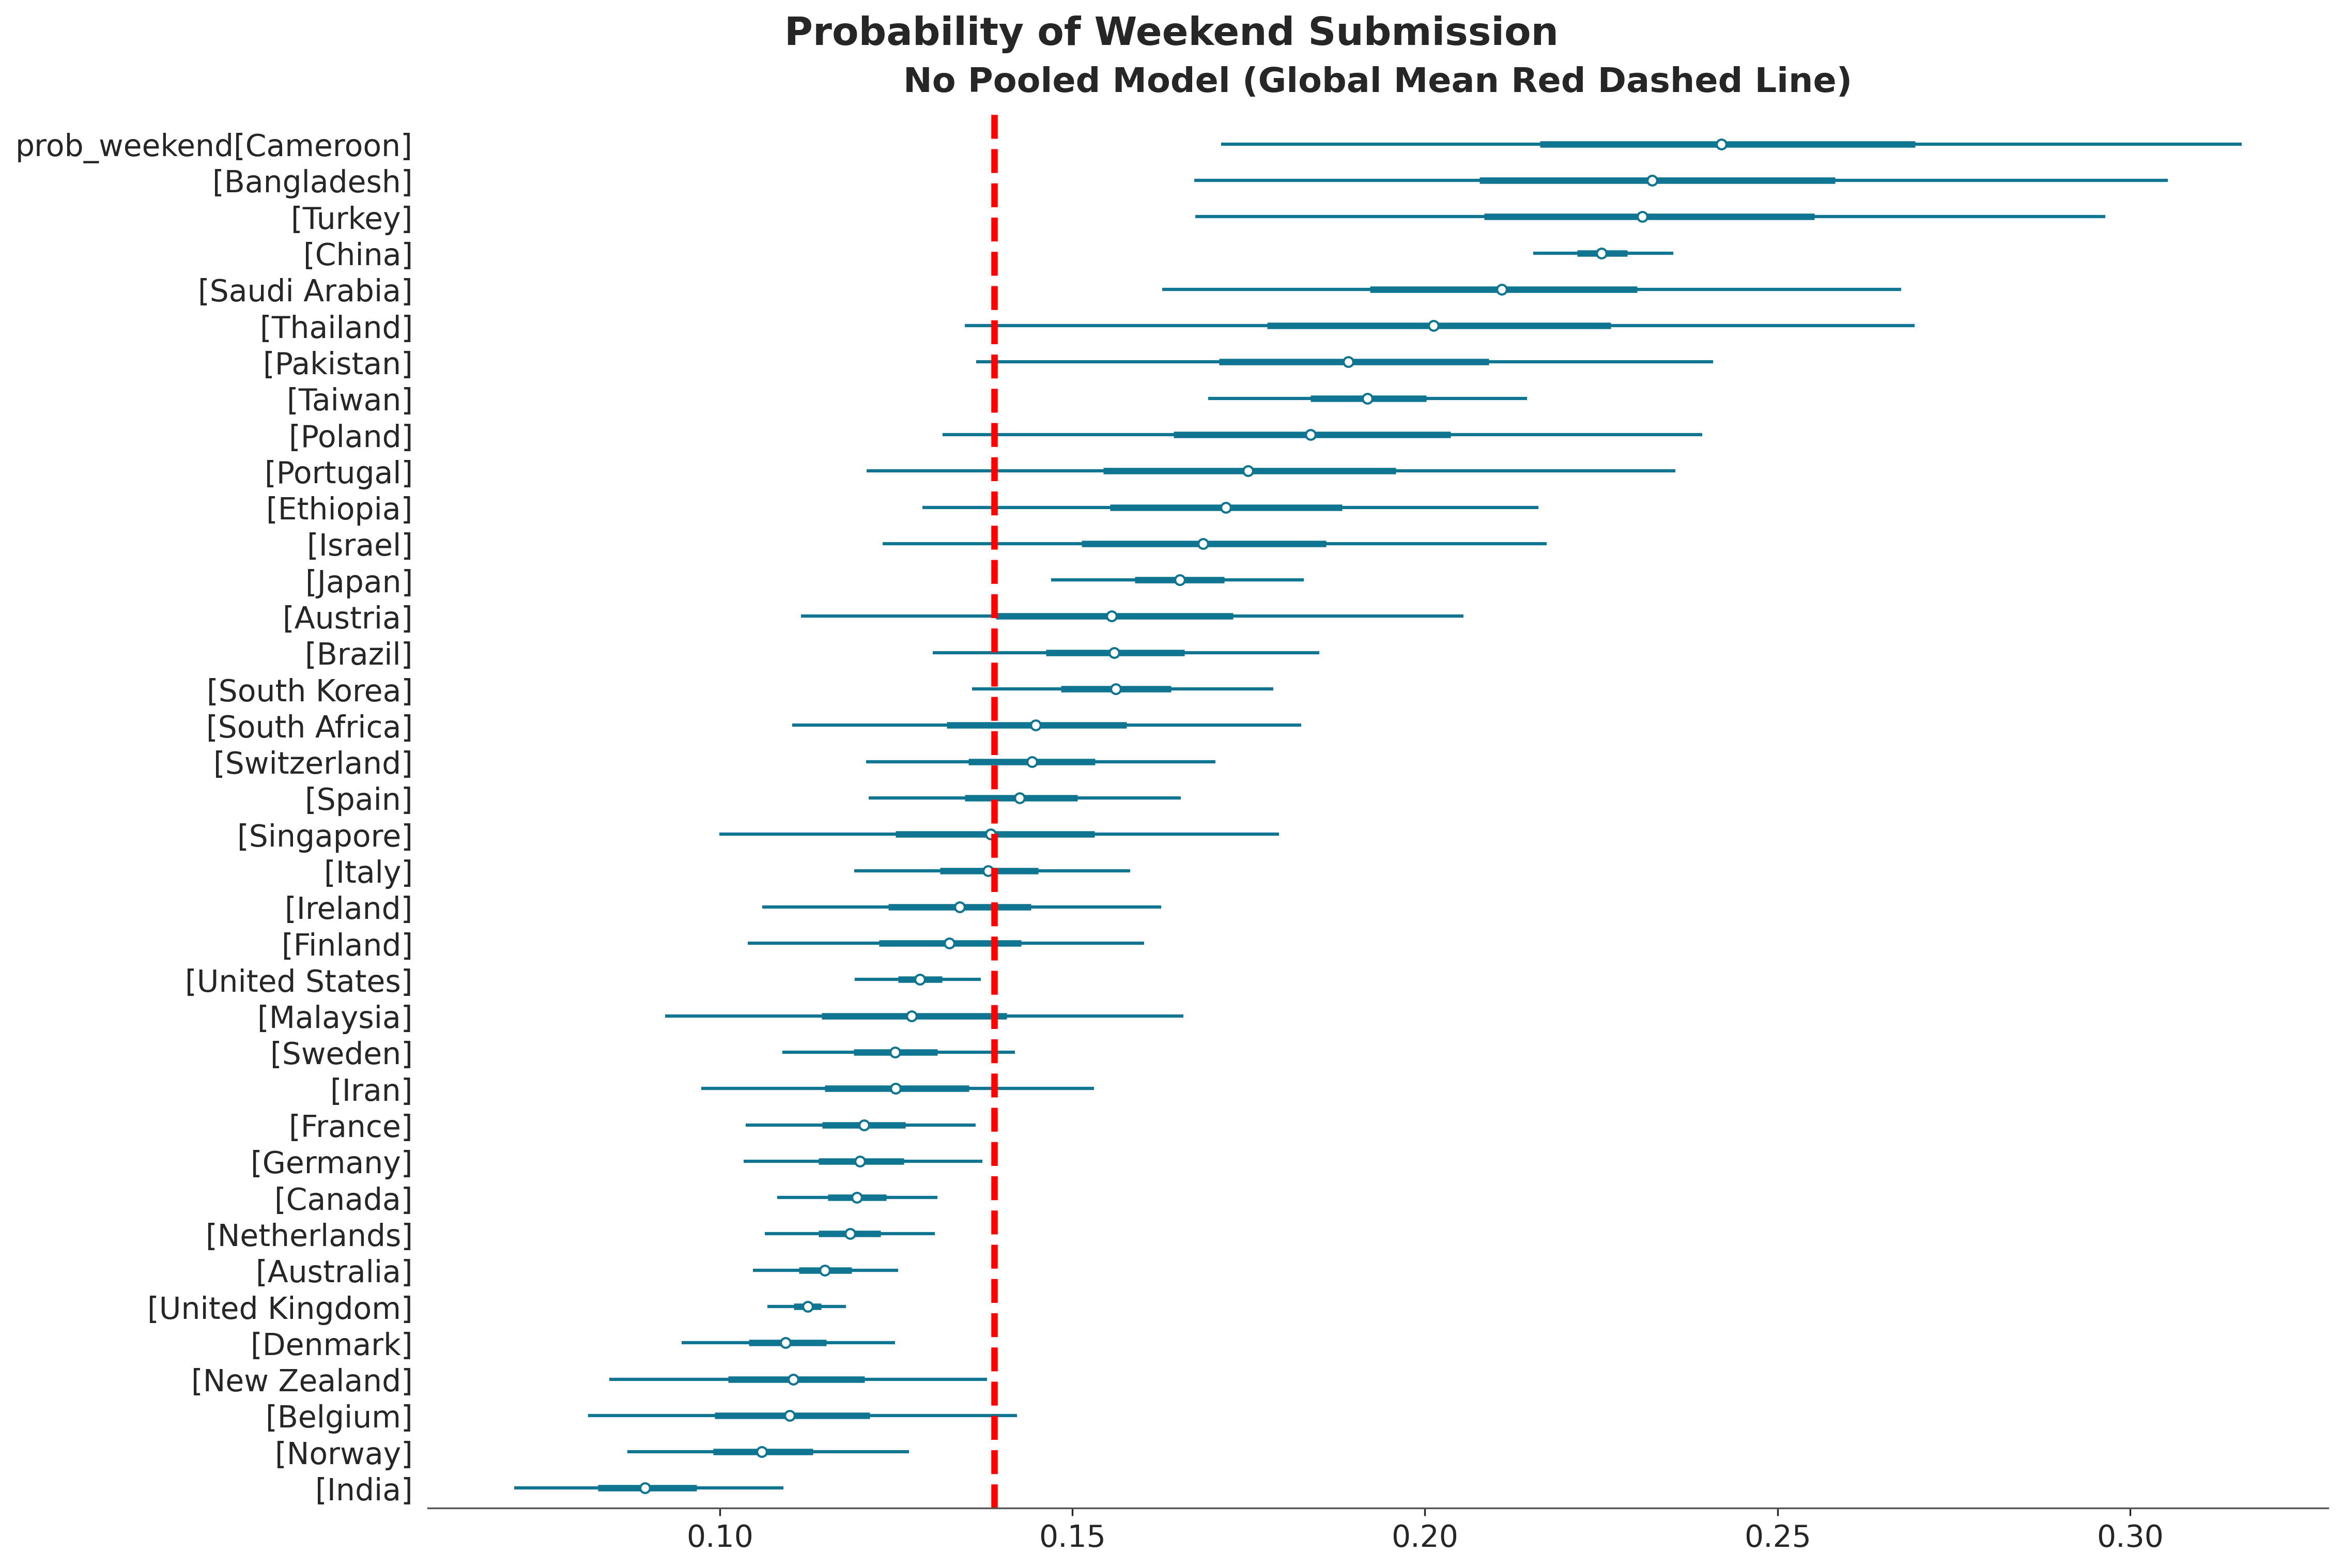

In [14]:
# Forest plot

global_mean = df["W"].mean()

fig, ax = plt.subplots(figsize=(15., 10.))
az.plot_forest(
    prob_weekend_no_pool.posterior["prob_weekend"][:, :, list(country_dict_sorted.values())],
    kind="forestplot",
    combined=True,
    ax=ax
)
ax.axvline(global_mean, color="red", ls="--", lw=3.)
plt.suptitle("Probability of Weekend Submission")
ax.set_title("No Pooled Model (Global Mean Red Dashed Line)")
plt.show()

## Partially Pooled Model
<center> $W \sim Bernoulli(p)$</center>
<center> $p = invlogit(a + b[\text{country\_id}])$</center>
<center> $a \sim Normal(-2, 1)$</center>
<center> $\sigma \sim Exponential(1.0)$ </center>
<center> $b[\text{country\_id}] \sim Normal(0, \sigma)$</center>

In [15]:
def partial_pooled_model(country_id:jnp.array = jnp.array(country_idx), W:jnp.array = jnp.array(df["W"].values) ) -> None:
    '''
    Partially Pooled model for weekend submission
    '''

    # Priors
    a = numpyro.sample("a", dist.Normal(loc=0., scale=1.))

    # Prior for sigma
    σ = numpyro.sample("σ", dist.Exponential(1.0))

    # Partial Pooling Prior for b
    n_countries = len(np.unique(country_idx))
    with numpyro.plate("country", n_countries):
        b = numpyro.sample("b", dist.Normal(0., σ))

    # Probability
    p = expit(a + b[country_id])

    # Likelihood
    likelihood = numpyro.sample("likelihood", dist.Bernoulli(p), obs=W)
    

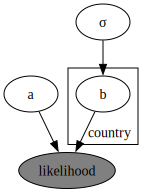

In [16]:
numpyro.render_model(partial_pooled_model)

In [17]:
# Sampling
rng_key, rng_subkey = split(rng_key)
partial_pooled_mcmc = MCMC(NUTS(partial_pooled_model), num_chains=4, num_warmup=1_000, num_samples=4_000)
partial_pooled_mcmc.run(rng_subkey)
partial_pooled_samples = partial_pooled_mcmc.get_samples()
partial_pooled_mcmc.print_summary()

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -1.77      0.05     -1.77     -1.85     -1.68   2024.98      1.00
      b[0]     -0.27      0.07     -0.27     -0.39     -0.15   3825.42      1.00
      b[1]      0.05      0.17      0.06     -0.24      0.32  16008.10      1.00
      b[2]      0.41      0.19      0.41      0.09      0.73  14915.90      1.00
      b[3]     -0.27      0.15     -0.26     -0.51     -0.01  11939.76      1.00
      b[4]      0.07      0.11      0.07     -0.11      0.26   7780.05      1.00
      b[5]      0.45      0.20      0.45      0.14      0.77  15240.04      1.00
      b[6]     -0.23      0.08     -0.23     -0.35     -0.10   3813.22      1.00
      b[7]      0.53      0.06      0.53      0.43      0.62   2435.95      1.00
      b[8]     -0.31      0.09     -0.31     -0.47     -0.16   5864.73      1.00
      b[9]      0.15      0.16      0.15     -0.10      0.42  14839.66      1.00
     b[10]     -0.10      0

In [18]:
# Probability of a weekend submission
prob_weekend_partial_pooled_ = vmap(lambda a, b: expit(a + b), in_axes=(0, 0))(partial_pooled_samples["a"], 
                                                                               partial_pooled_samples["b"])

In [19]:
idata_partial_pooled = az.from_numpyro(
    partial_pooled_mcmc,
    coords={"country": countries},
    dims={"b": ["country"]}
)
az.summary(idata_partial_pooled, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.77,0.05,-1.86,-1.66,0.0,0.0,2039.72,3812.29,1.0
b[Australia],-0.27,0.07,-0.41,-0.13,0.0,0.0,3853.20,6980.34,1.0
b[Austria],0.05,0.17,-0.27,0.37,0.0,0.0,16125.18,11741.24,1.0
b[Bangladesh],0.41,0.19,0.06,0.80,0.0,0.0,14932.35,10844.21,1.0
b[Belgium],-0.27,0.15,-0.55,0.03,0.0,0.0,12085.34,11327.97,1.0
b[Brazil],0.07,0.11,-0.14,0.28,0.0,0.0,7831.40,10039.68,1.0
b[Cameroon],0.45,0.20,0.09,0.82,0.0,0.0,15363.32,11732.90,1.0
b[Canada],-0.23,0.08,-0.36,-0.08,0.0,0.0,3860.30,7520.75,1.0
b[China],0.53,0.06,0.41,0.64,0.0,0.0,2455.07,5017.85,1.0
b[Denmark],-0.31,0.09,-0.49,-0.14,0.0,0.0,5963.46,8492.93,1.0


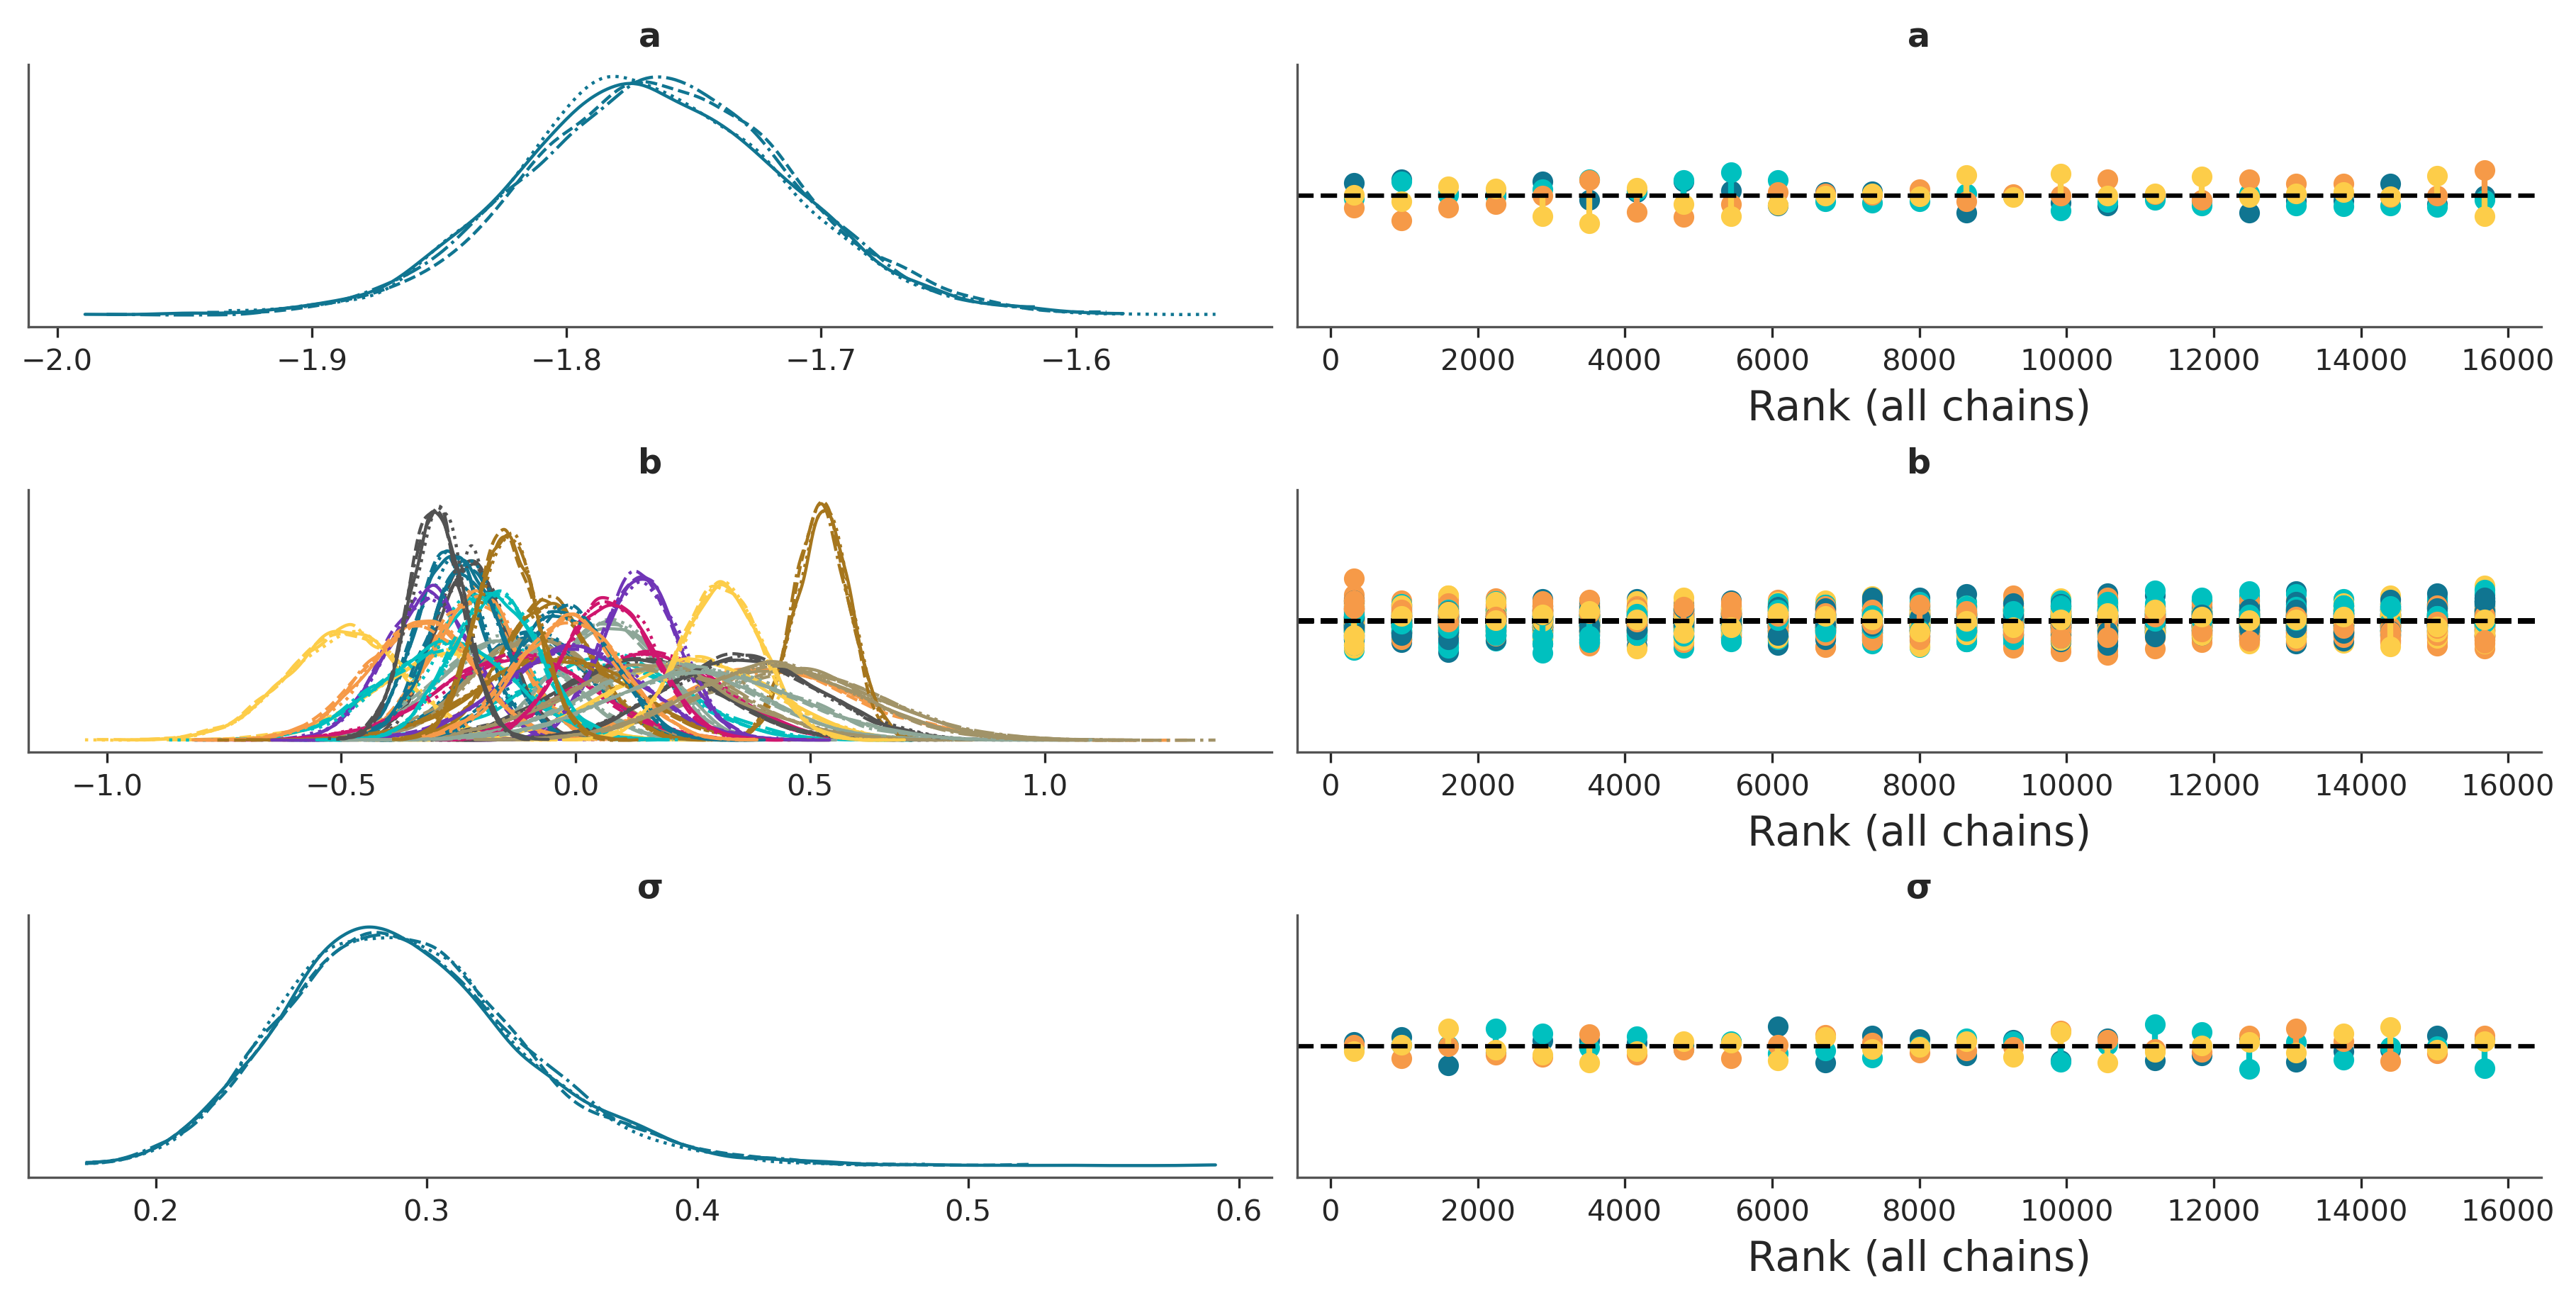

In [20]:
az.plot_trace(idata_partial_pooled, kind="rank_vlines")
plt.show()

In [21]:
# Forest plot for partial pooled model
prob_weekend_partial_pooled = az.from_dict(
    posterior = {"prob_weekend": prob_weekend_partial_pooled_.reshape(4, 4_000, -1)},
    coords={"country": countries},
    dims={"prob_weekend":["country"]}
    
)

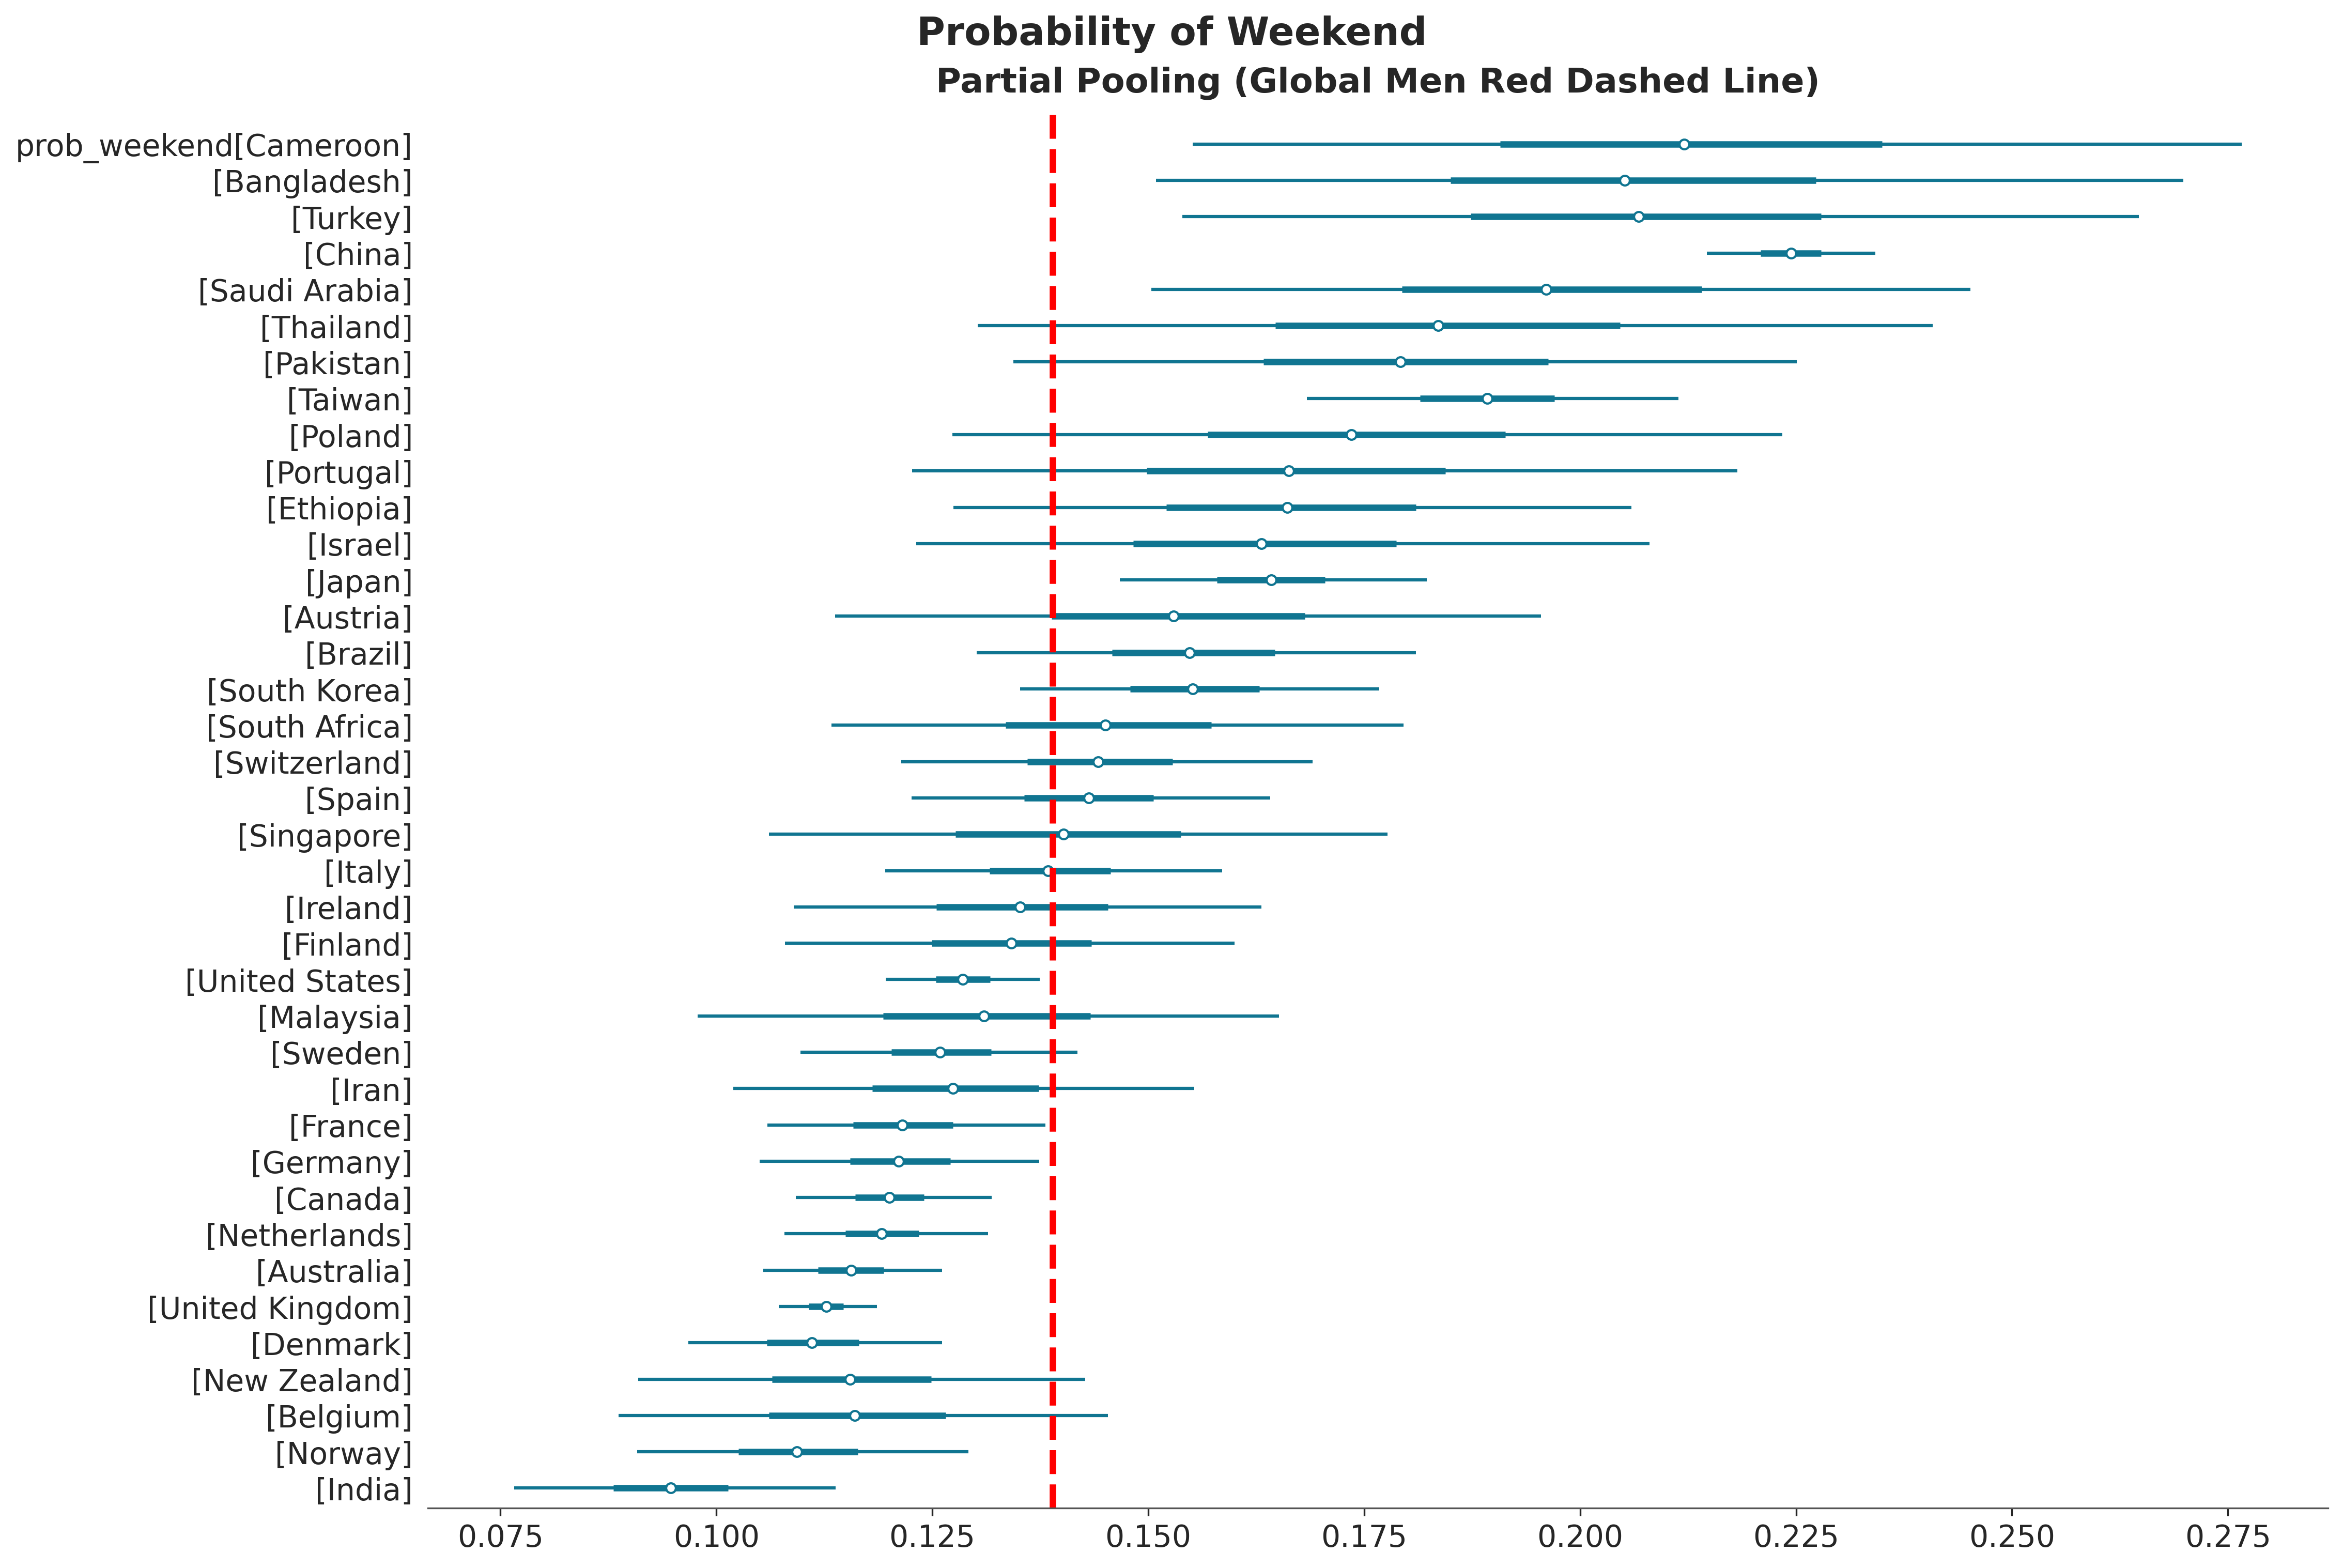

In [22]:
_, ax = plt.subplots(figsize=(15., 10.))
az.plot_forest(
    prob_weekend_partial_pooled.posterior["prob_weekend"][:, :, list(country_dict_sorted.values())],
    kind="forestplot",
    combined=True,
    ax=ax
)
ax.axvline(global_mean, color="red", ls="--", lw=3.)
plt.suptitle("Probability of Weekend")
ax.set_title("Partial Pooling (Global Men Red Dashed Line)")
plt.show()

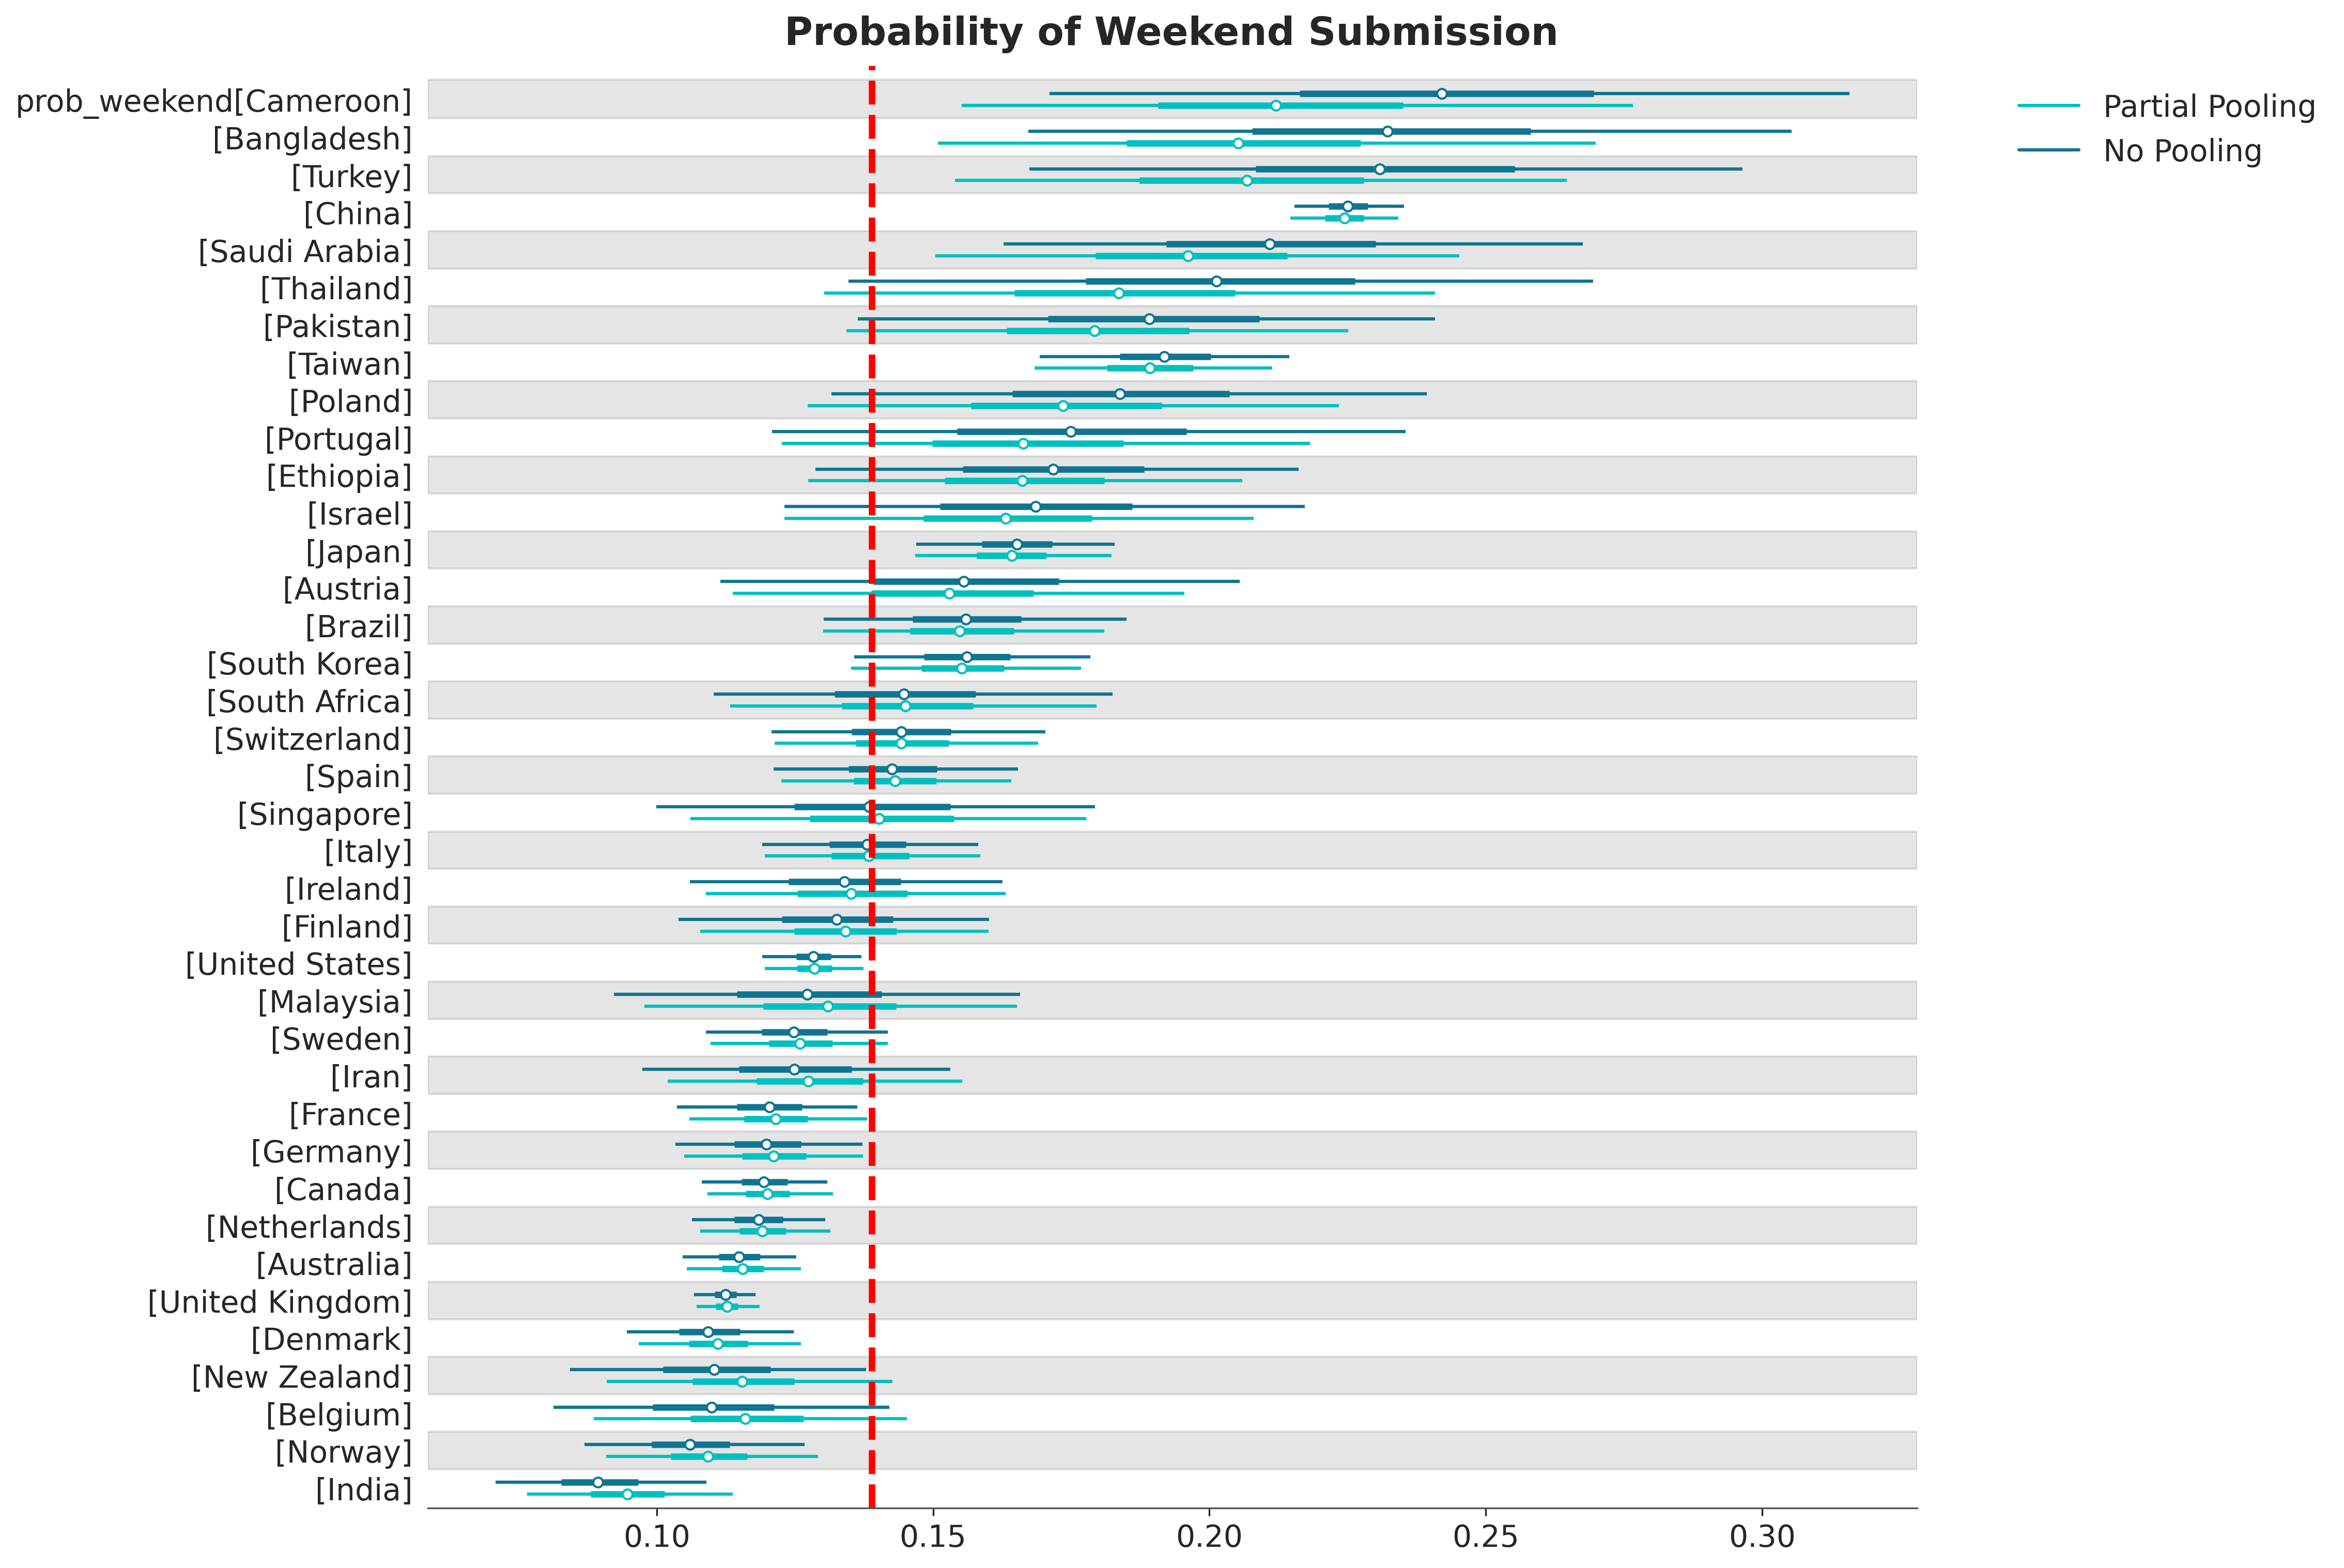

In [23]:
# Combined forest plot
_, ax = plt.subplots(figsize=(15., 10.))
c_idx = list(country_dict_sorted.values())
az.plot_forest(
    [
        prob_weekend_no_pool.posterior["prob_weekend"][:, :, c_idx],
        prob_weekend_partial_pooled.posterior["prob_weekend"][:, :, c_idx]
    ],
    model_names = ["No Pooling", "Partial Pooling"],
    combined=True,
    kind="forestplot",
    ax=ax
)
ax.axvline(global_mean, color="red", ls="--", lw=3)
plt.suptitle("Probability of Weekend Submission")
ax.set_title("")
leg = ax.get_legend()

# Move it outside (e.g., to the right)
leg.set_bbox_to_anchor((1.05, 1))
leg.set_loc('upper left')

plt.show()